# Poker Analytics Copilot

In [69]:
import pandas as pd

In [70]:
df = pd.read_csv("poker_analytics_data.csv")
df.head()

,Time,Date,Site,Stake,My C Bet PF,Position,Saw Flop,Saw Turn,Saw River,Final Hand,...,My C Bet T,River,R Act,My C Bet R,Winner,Winning Hand,Pot,Pot (BB),Won,BB Won
0,3:21 pm,2026/06/23 3:21 pm,GGP,$0.25 NL FAST (6 max),$0.25,BB,True,False,False,(folded flop),...,$0.00,0,NaN,$0.00,b31dd87,(did not show hand),$0.60,2,-$0.25,-1.0
1,3:21 pm,2026/06/23 3:21 pm,GGP,$0.25 NL FAST (6 max),$0.10,SB,False,False,False,(folded preflop),...,$0.00,0,NaN,$0.00,64adeaf1,(did not show hand),$0.60,2,-$0.10,-0.4
2,3:21 pm,2026/06/23 3:21 pm,GGP,$0.25 NL FAST (6 max),$0.25,BB,False,False,False,(did not show hand),...,$0.00,0,NaN,$0.00,RoccoJustice,(did not show hand),$0.20,1,$0.10,0.4
3,3:21 pm,2026/06/23 3:21 pm,GGP,$0.25 NL FAST (6 max),$0.00,CO,False,False,False,(folded preflop),...,$0.00,0,NaN,$0.00,52bc0998,(did not show hand),$0.20,1,$0.00,0.0
4,3:21 pm,2026/06/23 3:21 pm,GGP,$0.25 NL FAST (6 max),$0.25,BB,False,False,False,(did not show hand),...,$0.00,0,NaN,$0.00,RoccoJustice,(did not show hand),$0.20,1,$0.10,0.4


In [71]:
df.columns.tolist()

['Time',
 'Date',
 'Site',
 'Stake',
 'My C Bet PF',
 'Position',
 'Saw Flop',
 'Saw Turn',
 'Saw River',
 'Final Hand',
 'Hole Cards',
 'Facing PF Action',
 'Preflop SPR',
 'PF Act',
 'Flop Made Hand',
 'Flop SPR',
 'Flop',
 'F Act',
 'Bet F',
 'Turn',
 'T Act',
 'My C Bet T',
 'River',
 'R Act',
 'My C Bet R',
 'Winner',
 'Winning Hand',
 'Pot',
 'Pot (BB)',
 'Won',
 'BB Won']

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14148 entries, 0 to 14147
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Time              14148 non-null  str    
 1   Date              14148 non-null  str    
 2   Site              14148 non-null  str    
 3   Stake             14148 non-null  str    
 4   My C Bet PF       14148 non-null  str    
 5   Position          14148 non-null  str    
 6   Saw Flop          14148 non-null  bool   
 7   Saw Turn          14148 non-null  bool   
 8   Saw River         14148 non-null  bool   
 9   Final Hand        14148 non-null  str    
 10  Hole Cards        14148 non-null  str    
 11  Facing PF Action  14148 non-null  str    
 12  Preflop SPR       14148 non-null  int64  
 13  PF Act            13809 non-null  str    
 14  Flop Made Hand    2219 non-null   str    
 15  Flop SPR          14148 non-null  str    
 16  Flop              14148 non-null  str    
 17  F Ac

## What is my winrate by position in bb/100?

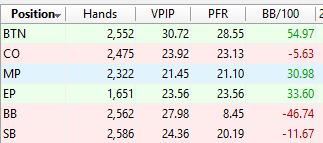

In [73]:
# Casting "BB Won" to numeric, coercing errors to NaN
df["BB Won"] = pd.to_numeric(df["BB Won"], errors="coerce")

result = (
    df.groupby("Position")
    .agg(
        hands=("Position", "count"),
        bb_won=("BB Won", "sum"),
        avg_bb_per_hand=("BB Won", "mean")
    )
    .sort_values("bb_won", ascending=False)
)

print(result)

          hands   bb_won  avg_bb_per_hand
Position                                 
BTN        2552  1402.78         0.549679
MP         2322   719.30         0.309776
EP         1651   554.66         0.335954
CO         2475  -139.25        -0.056263
SB         2586  -301.77        -0.116694
BB         2562 -1197.51        -0.467412


In [74]:
result["bb_per_100"] = result["avg_bb_per_hand"] * 100

result = result.sort_values("bb_per_100", ascending=False)

print(result)

          hands   bb_won  avg_bb_per_hand  bb_per_100
Position                                             
BTN        2552  1402.78         0.549679   54.967868
EP         1651   554.66         0.335954   33.595397
MP         2322   719.30         0.309776   30.977606
CO         2475  -139.25        -0.056263   -5.626263
SB         2586  -301.77        -0.116694  -11.669374
BB         2562 -1197.51        -0.467412  -46.741218


## What is my winrate per site?

In [75]:
result = (
    df.groupby("Site")
    .agg(
        hands=("Position", "count"),
        bb_won=("BB Won", "sum"),
        avg_bb_per_hand=("BB Won", "mean")
    )
    .sort_values("bb_won", ascending=False)
)

result["bb_per_100"] = result["avg_bb_per_hand"] * 100

result = result.sort_values("bb_per_100", ascending=False)

print(result)

      hands   bb_won  avg_bb_per_hand  bb_per_100
Site                                             
GGP   14148  1038.21         0.073382     7.33821


## Whats is my 3bet by position?

In [76]:
# Understanding the distribution of "Facing PF Action" to identify 3-bet opportunities
df["Facing PF Action"].value_counts()

Facing PF Action
Unopened Pot           7087
1 Raiser               4524
1 Limper                754
1 Raise & Caller(s)     750
3Bet Cold               587
All players fold        339
2+ Limpers               94
4Bet Cold                10
Error                     3
Name: count, dtype: int64

In [77]:
# How is 3Bet represented in the "PF Act" column? Let's check the unique values in that column to understand how 3Bets are recorded.
df["PF Act"].value_counts()

PF Act
F      10103
R       2240
C        599
RF       427
X        191
RC       165
RR        47
CF        20
CC         8
RRC        5
RRR        2
RRF        2
Name: count, dtype: int64

In [78]:
# 3Bet opportunities
opps = df[df["Facing PF Action"] == "1 Raiser"].copy()
opps.shape

(4524, 31)

In [79]:
# Create a new column to indicate if the player 3-bet or not
# opps["is_3bet"] = opps["PF Act"].apply(lambda x: 1 if x.startswith("R") else 0) -> same output but slower than str.startswith and
# cast to int at the same time
opps["is_3bet"] = opps["PF Act"].str.startswith("R")
opps["is_3bet"].value_counts()

is_3bet
False    4154
True      370
Name: count, dtype: int64

In [80]:
result = (
    opps.groupby("Position")
    .agg(
        opportunities=("is_3bet", "count"),
        threebets=("is_3bet", "sum")
    )
)

result

,opportunities,threebets
Position,,
BB,1278,103
BTN,1013,90
CO,664,48
MP,326,21
SB,1243,108


In [81]:
result["threebet_pct"] = (
    result["threebets"] /
    result["opportunities"] * 100
)

result.sort_values("threebet_pct", ascending=False)

,opportunities,threebets,threebet_pct
Position,,,
BTN,1013,90,8.884501
SB,1243,108,8.688656
BB,1278,103,8.059468
CO,664,48,7.228916
MP,326,21,6.441718


### Importing functions created in analytics.py

In [82]:
from analytics import (
    winrate_by_position,
    winrate_by_site,
    threebet_by_position
)

In [83]:
winrate_by_position(df)

,hands,bb_won,avg_bb_per_hand,bb_per_100
Position,,,,
BTN,2552,1402.78,0.549679,54.967868
EP,1651,554.66,0.335954,33.595397
MP,2322,719.30,0.309776,30.977606
CO,2475,-139.25,-0.056263,-5.626263
SB,2586,-301.77,-0.116694,-11.669374
BB,2562,-1197.51,-0.467412,-46.741218


In [84]:
winrate_by_site(df)

,hands,bb_won,avg_bb_per_hand,bb_per_100
Site,,,,
GGP,14148,1038.21,0.073382,7.33821


In [85]:
threebet_by_position(df)

,opportunities,threebets,threebet_pct
Position,,,
BTN,1013,90,8.884501
SB,1243,108,8.688656
BB,1278,103,8.059468
CO,664,48,7.228916
MP,326,21,6.441718


## Importing query router from query_router.py

In [86]:
import importlib
import query_router

importlib.reload(query_router)

dir(query_router)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'run_query',
 'threebet_by_position',
 'winrate_by_position',
 'winrate_by_site']

In [87]:
from query_router import run_query

run_query("threebet_position", df)

,opportunities,threebets,threebet_pct
Position,,,
BTN,1013,90,8.884501
SB,1243,108,8.688656
BB,1278,103,8.059468
CO,664,48,7.228916
MP,326,21,6.441718


## Integrating LLM to parse NL into function names

In [88]:
import sys
print(sys.executable)

c:\Users\Lesinho\anaconda3\envs\venv\python.exe


In [89]:
import sys
!{sys.executable} -m pip install python-dotenv

In [90]:
!{sys.executable} -m pip install openai python-dotenv

In [91]:
import json
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

client = OpenAI()


AVAILABLE_QUERIES = [
    "winrate_position",
    "winrate_site",
    "threebet_position",
]


def parse_user_query(user_question: str) -> dict:
    system_prompt = f"""
You are a query parser for a poker analytics application.

Your job is to map the user's natural language question to one of the available query names.

Available query names:
{AVAILABLE_QUERIES}

Return ONLY valid JSON.

JSON format:
{{
  "query_name": "one_of_the_available_query_names"
}}

If the question does not match any available query, return:
{{
  "query_name": "unknown"
}}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_question},
        ],
        temperature=0,
    )

    content = response.choices[0].message.content

    return json.loads(content)

In [92]:
from llm_parser import parse_user_query

parse_user_query("Calcula mi winrate por posición")

{'query_name': 'winrate_position'}

In [93]:
parse_user_query("Dame mi 3bet por posición")

{'query_name': 'threebet_position'}

In [94]:
from llm_parser import parse_user_query
from query_router import run_query

user_question = "Dame mi 3bet por posición"

parsed_query = parse_user_query(user_question)
query_name = parsed_query["query_name"]

result = run_query(query_name, df)

result

,opportunities,threebets,threebet_pct
Position,,,
BTN,1013,90,8.884501
SB,1243,108,8.688656
BB,1278,103,8.059468
CO,664,48,7.228916
MP,326,21,6.441718


## Making a more intelligent parser

In [96]:
import importlib
import llm_parser

importlib.reload(llm_parser)

from llm_parser import parse_user_query

In [97]:
parse_user_query("Calcula mi porcentaje de raise cuando alguien ya abrió el bote antes que yo")

{'query_name': 'threebet_position'}

In [98]:
parsed_query = parse_user_query(
    "Calcula mi porcentaje de raise cuando alguien ya abrió el bote antes que yo"
)

query_name = parsed_query["query_name"]

result = run_query(query_name, df)

result

,opportunities,threebets,threebet_pct
Position,,,
BTN,1013,90,8.884501
SB,1243,108,8.688656
BB,1278,103,8.059468
CO,664,48,7.228916
MP,326,21,6.441718
